# Continuation from `cipt_example.ipynb`

Need to run the notebook `cipt_example.ipynb` first to generate the data for this notebook.

# CIPT Finite-Size Scaling Analysis

Data collapse of the steady-state magnetization from `cipt_example.ipynb` (Julia), using the [FSS](https://github.com/hainingpan/FSS) package:

$$M_z(p, L) \sim L^{-\beta/\nu} \, f\big[(p - p_c)\, L^{1/\nu}\big]$$

**Pipeline**: run `cipt_example.ipynb` first → it writes `cipt_Mz_data.csv` → this notebook fits it.

```bash
pip install git+https://github.com/hainingpan/FSS.git
```

In [1]:
import pandas as pd
from fss import DataCollapse

df = (pd.read_csv("cipt_Mz_data.csv", comment="#")
        .rename(columns={"Mz_mean": "estimator", "Mz_sem": "standard_error"})
        .set_index(["p", "L"])
        .sort_index())

dc = DataCollapse(df, p_="p", L_="L", p_range=[0.4, 0.6], estimator="manual")

## Raw data

Curves for different $L$ should cross near $p_c$.

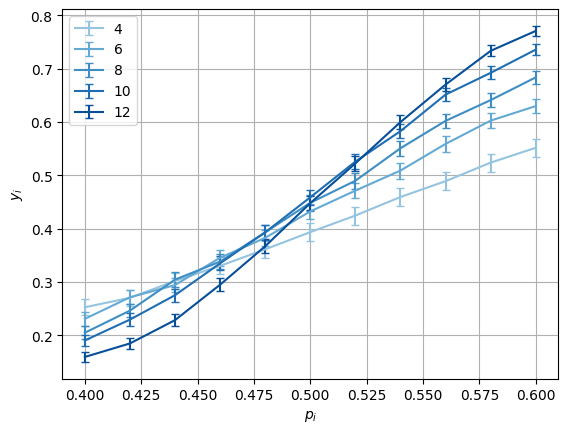

In [2]:
dc.plot_data_collapse(raw=True, errorbar=True)

## Data collapse

Fit $p_c$ and $\nu$, holding $\beta = 0$ (set `beta_vary=True` for a nontrivial order-parameter exponent).

In [3]:
res = dc.datacollapse(p_c=0.491, nu=1.0, beta=0.0,
                      p_c_vary=True, nu_vary=True, beta_vary=False)
res

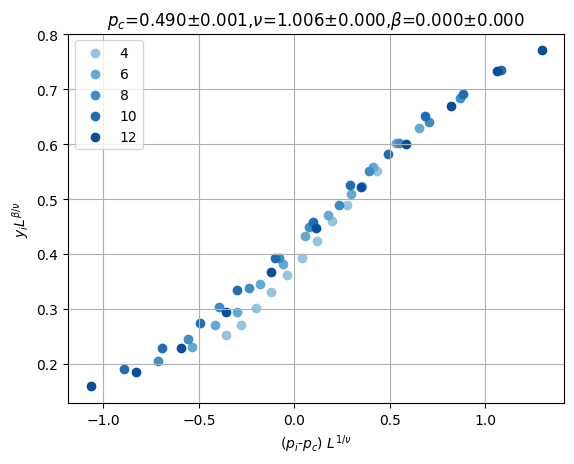

In [4]:
dc.plot_data_collapse()